In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from IPython.display import display
#datasets
path = "C:\\Users\\Aaron Lim\\Dropbox\\PC\\Documents\\School Slides Materials\\3rd Year- Tri 2\\Data Mining\\Final Assignment (Student Grade)\\"
courses = pd.read_csv(path + 'courses.csv')
assessments = pd.read_csv(path + 'assessments.csv')
vle = pd.read_csv(path + 'vle.csv')
studentInfo = pd.read_csv(path + 'studentInfo.csv')
studentReg = pd.read_csv(path + 'studentRegistration.csv')
studentAssess = pd.read_csv(path + 'studentAssessment.csv')
studentVle = pd.read_csv(path + 'studentVle.csv', engine='python', on_bad_lines='skip')


print("All datasets loaded successfully.")

All datasets loaded successfully.


**Data Understanding & Exploration**
1. Load data
2. Check structure, types, missing values
3. Detect outliers ← box plots, IQR analysis
4. Visualize distributions

In [3]:
dfs = {
    "studentInfo": studentInfo,
    "studentReg": studentReg,
    "studentAssess": studentAssess,
    "studentVle": studentVle,
    "assessments": assessments,
    "vle": vle,
    "courses": courses
}


In [4]:
# Function to display data structure information
def data_structure(name, df):
    print(name)
    print("Shape:",df.shape)
    print("Columns:", list(df.columns))
    print("Missing Values:", df.isnull().sum()[df.isnull().sum() > 0])
    print("\n")

# Display data structure information for each dataframe
for name, df in dfs.items():
    data_structure(name, df)

studentInfo
Shape: (32593, 12)
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
Missing Values: imd_band    1111
dtype: int64


studentReg
Shape: (32593, 5)
Columns: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']
Missing Values: date_registration         45
date_unregistration    22521
dtype: int64


studentAssess
Shape: (173912, 5)
Columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
Missing Values: score    173
dtype: int64


studentVle
Shape: (10655280, 6)
Columns: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
Missing Values: Series([], dtype: int64)


assessments
Shape: (206, 6)
Columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
Missing Values: date    11
dtype: int64


vle
Sh

In [5]:
# Display the first 5 rows of the main student table
display(studentInfo.head())

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [6]:
# Set pandas to display regular numbers (not scientific notation)
pd.set_option('display.float_format', '{:.2f}'.format)

# Display statistics for numeric columns
for name, df in dfs.items():
    print(f"\n{name}:")
    print(df.describe())


studentInfo:
       id_student  num_of_prev_attempts  studied_credits
count    32593.00              32593.00         32593.00
mean    706687.67                  0.16            79.76
std     549167.31                  0.48            41.07
min       3733.00                  0.00            30.00
25%     508573.00                  0.00            60.00
50%     590310.00                  0.00            60.00
75%     644453.00                  0.00           120.00
max    2716795.00                  6.00           655.00

studentReg:
       id_student  date_registration  date_unregistration
count    32593.00           32548.00             10072.00
mean    706687.67             -69.41                49.76
std     549167.31              49.26                82.46
min       3733.00            -322.00              -365.00
25%     508573.00            -100.00                -2.00
50%     590310.00             -57.00                27.00
75%     644453.00             -29.00               109

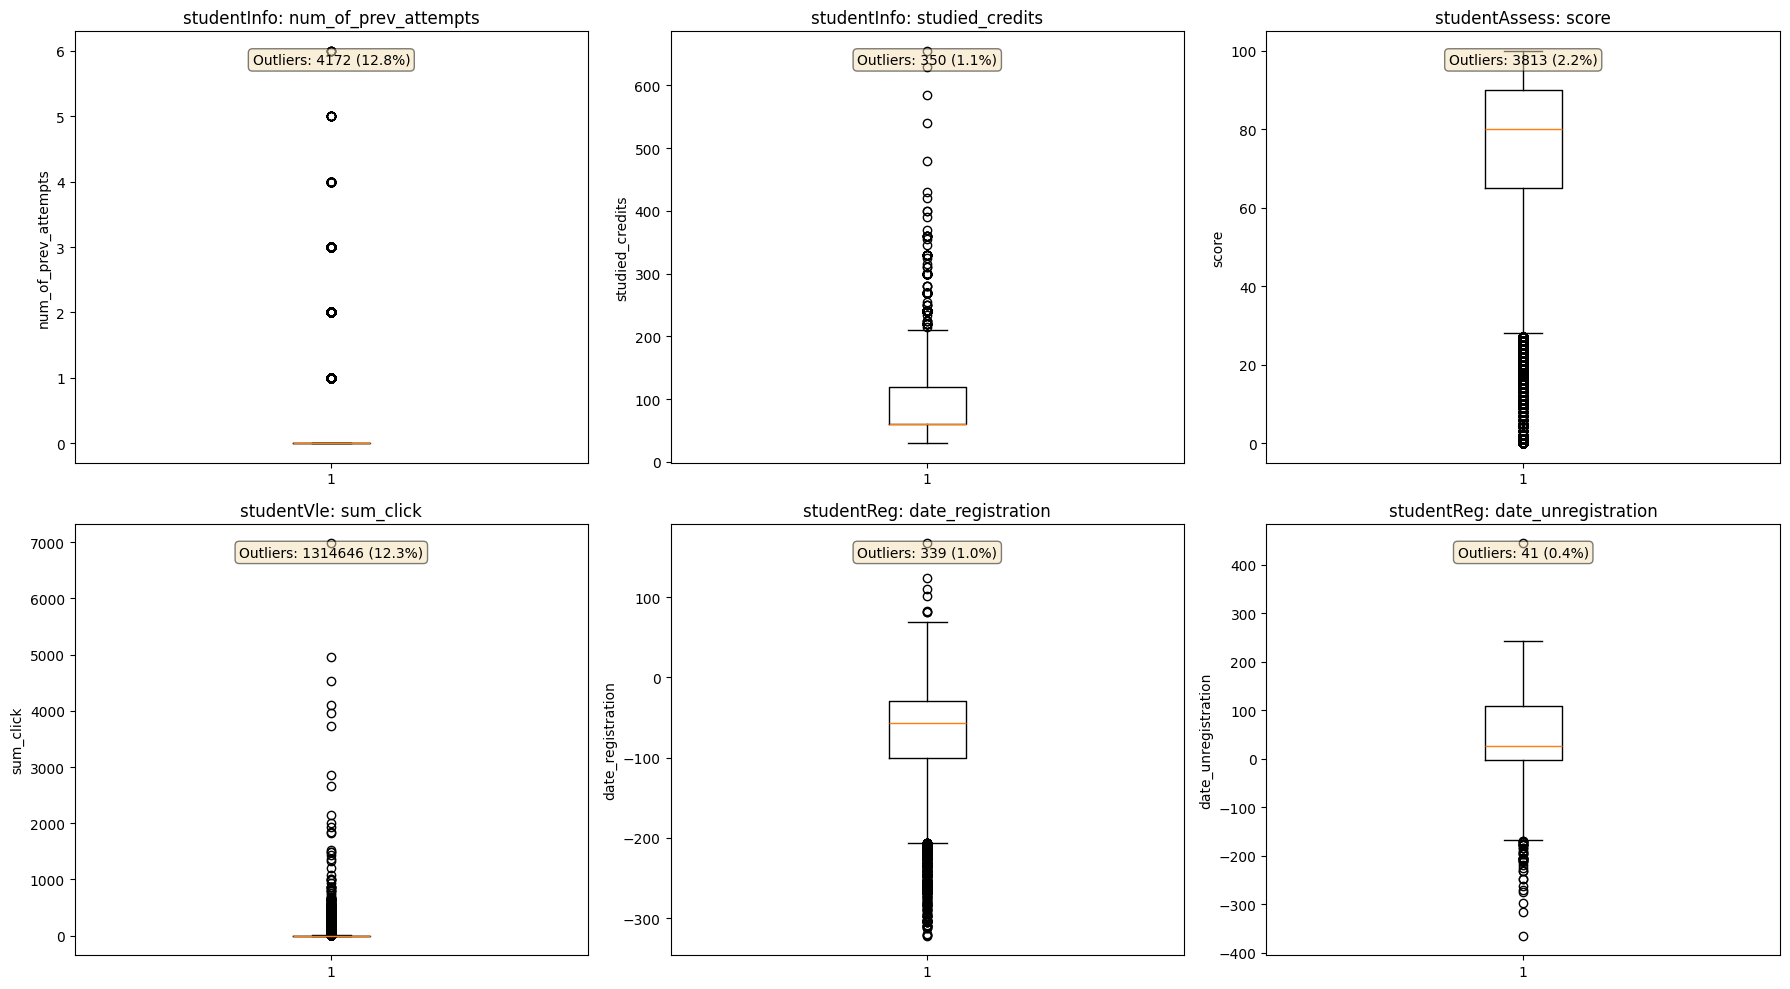


=== IQR-Based Outlier Summary ===
studentInfo.num_of_prev_attempts: 4172 outliers (12.80%) | Range: [0.0, 0.0]
studentInfo.studied_credits: 350 outliers (1.07%) | Range: [-30.0, 210.0]
studentAssess.score: 3813 outliers (2.19%) | Range: [27.5, 127.5]
studentVle.sum_click: 1314646 outliers (12.34%) | Range: [-2.0, 6.0]
studentReg.date_registration: 339 outliers (1.04%) | Range: [-206.5, 77.5]
studentReg.date_unregistration: 41 outliers (0.41%) | Range: [-168.5, 275.5]


In [7]:
# Create box plots for key numeric columns to visualize outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Select key numeric columns to check for outliers
outlier_check_cols = [
    ('studentInfo', 'num_of_prev_attempts'),
    ('studentInfo', 'studied_credits'),
    ('studentAssess', 'score'),
    ('studentVle', 'sum_click'),
    ('studentReg', 'date_registration'),
    ('studentReg', 'date_unregistration')
]

for idx, (df_name, col) in enumerate(outlier_check_cols):
    if df_name in dfs and col in dfs[df_name].columns:
        data = dfs[df_name][col].dropna()

        # Box plot
        axes[idx].boxplot(data, vert=True)
        axes[idx].set_title(f'{df_name}: {col}')
        axes[idx].set_ylabel(col)

        # Calculate IQR-based outlier count
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data < lower_bound) | (data > upper_bound)]

        axes[idx].text(0.5, 0.95, f'Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)',
                      transform=axes[idx].transAxes, ha='center', va='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n=== IQR-Based Outlier Summary ===")
for df_name, col in outlier_check_cols:
    if df_name in dfs and col in dfs[df_name].columns:
        data = dfs[df_name][col].dropna()
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        print(f"{df_name}.{col}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.2f}%) | Range: [{lower_bound:.1f}, {upper_bound:.1f}]")

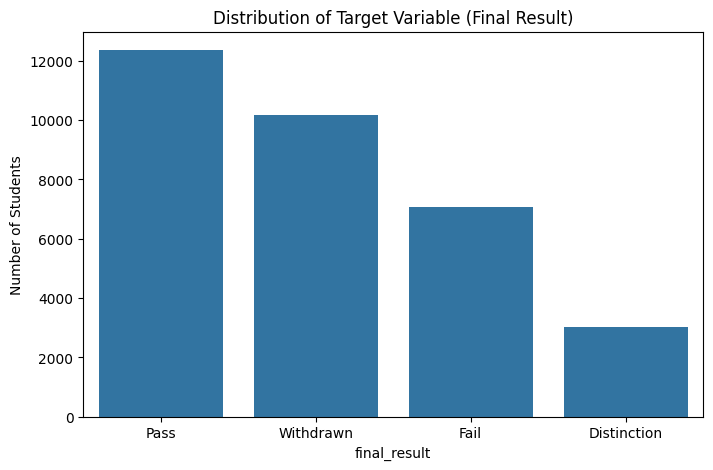

Target Value Counts:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


In [8]:
#Target Variable Analysis
plt.figure(figsize=(8, 5))
sns.countplot(data=studentInfo, x='final_result')
plt.title('Distribution of Target Variable (Final Result)')
plt.ylabel('Number of Students')
plt.show()

print("Target Value Counts:")
print(studentInfo['final_result'].value_counts())

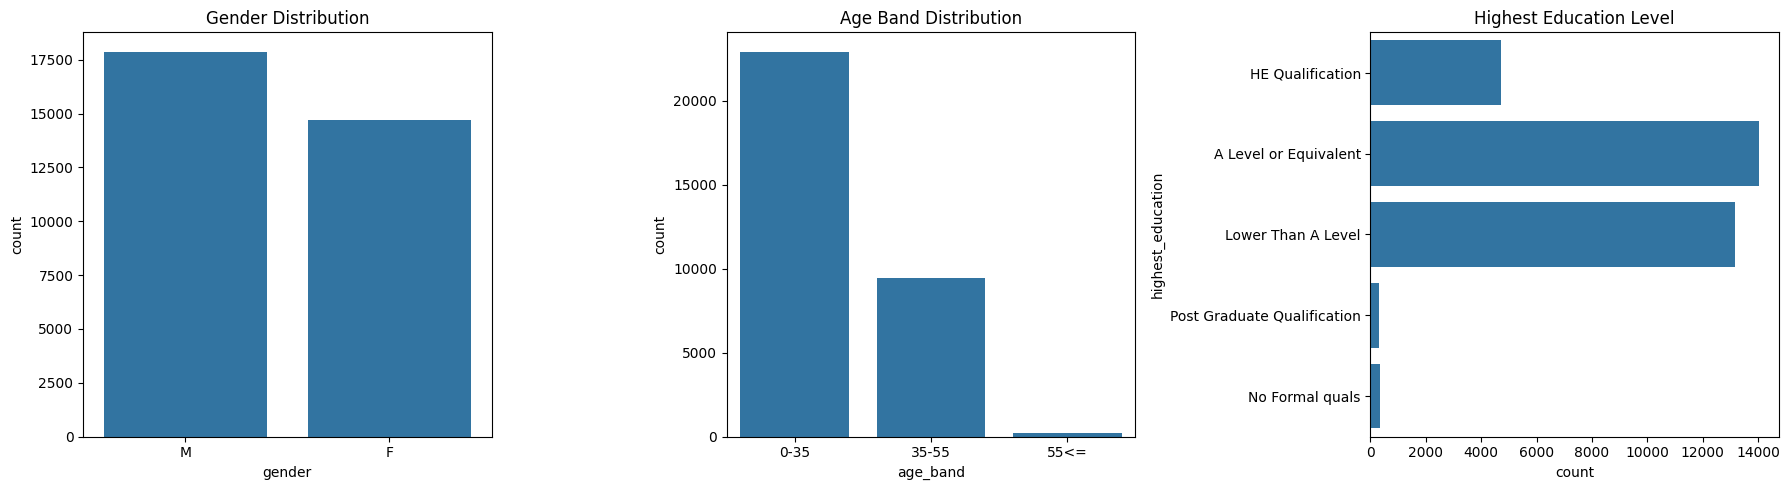

In [9]:
# Demographic Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#gender
sns.countplot(data=studentInfo, x='gender', ax=axes[0])
axes[0].set_title('Gender Distribution')

#age band
sns.countplot(data=studentInfo, x='age_band', ax=axes[1],order=['0-35', '35-55', '55<='])
axes[1].set_title('Age Band Distribution')

#education
sns.countplot(data=studentInfo, y='highest_education', ax=axes[2])
axes[2].set_title('Highest Education Level')

plt.tight_layout()
plt.show()

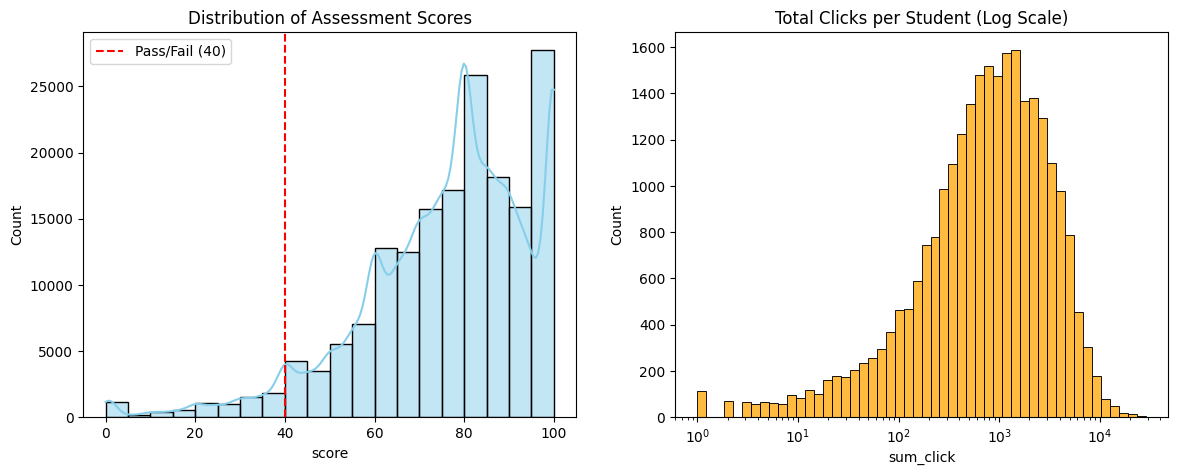

In [10]:
# initial check of scores & egagement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scores (from studentAssess)
sns.histplot(studentAssess['score'].dropna(), bins=20, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Distribution of Assessment Scores')
axes[0].axvline(40, color='red', linestyle='--', label='Pass/Fail (40)')
axes[0].legend()

# Engagement (from studentVle)
clicks_per_student = studentVle.groupby('id_student')['sum_click'].sum()
sns.histplot(clicks_per_student, bins=50, ax=axes[1], color='orange', log_scale=True)
axes[1].set_title('Total Clicks per Student (Log Scale)')

plt.show()

**Data Preprocessing & Integration**
1. Data Integraton
2. Handle outliers ← decide to keep, remove, cap, or transform (e.g., log transformation)
3. Impute missing values
4. Correlation analysis
5. Encode categoricals

In [11]:
#Data aggregration
#VLE Interactions
vle_interaction = studentVle.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].sum().reset_index()
vle_interaction.rename(columns={'sum_click': 'total_clicks'}, inplace=True)
active_days = studentVle.groupby(['code_module', 'code_presentation', 'id_student'])['date'].nunique().reset_index()
active_days.rename(columns={'date': 'active_days_count'}, inplace=True)

print(vle_interaction.head())
print(active_days.head())

  code_module code_presentation  id_student  total_clicks
0         AAA             2013J       11391           934
1         AAA             2013J       28400          1435
2         AAA             2013J       30268           281
3         AAA             2013J       31604          2158
4         AAA             2013J       32885          1034
  code_module code_presentation  id_student  active_days_count
0         AAA             2013J       11391                 40
1         AAA             2013J       28400                 80
2         AAA             2013J       30268                 12
3         AAA             2013J       31604                123
4         AAA             2013J       32885                 70


In [12]:
#Assessment Scores
student_assess_merged = pd.merge(studentAssess, assessments, on='id_assessment', how='left')
avg_scores = student_assess_merged.groupby(['code_module', 'code_presentation', 'id_student'])['score'].mean().reset_index()
avg_scores.rename(columns={'score': 'mean_score'}, inplace=True)
#TRUE if submission after due date
student_assess_merged['is_late'] = (student_assess_merged['date_submitted'] > student_assess_merged['date']) & (student_assess_merged['date'].notna())
#rate of late submission
late_rate = student_assess_merged.groupby(['code_module', 'code_presentation', 'id_student'])['is_late'].mean().reset_index()
late_rate.rename(columns={'is_late': 'late_submission_rate'}, inplace=True)

print(avg_scores.head())
print(late_rate.head())

  code_module code_presentation  id_student  mean_score
0         AAA             2013J       11391       82.00
1         AAA             2013J       28400       66.40
2         AAA             2013J       31604       76.00
3         AAA             2013J       32885       54.40
4         AAA             2013J       38053       68.00
  code_module code_presentation  id_student  late_submission_rate
0         AAA             2013J       11391                  0.00
1         AAA             2013J       28400                  0.40
2         AAA             2013J       31604                  0.00
3         AAA             2013J       32885                  1.00
4         AAA             2013J       38053                  0.20


In [13]:
#Data integration
merged_df = pd.merge(studentInfo, studentReg,
                     on=['code_module', 'code_presentation', 'id_student'],
                     how='left')

merged_df = pd.merge(merged_df, vle_interaction,
                     on=['code_module', 'code_presentation', 'id_student'],
                     how='left')

merged_df = pd.merge(merged_df, active_days,
                     on=['code_module', 'code_presentation', 'id_student'], how='left')

merged_df = pd.merge(merged_df, avg_scores,
                     on=['code_module', 'code_presentation', 'id_student'],
                     how='left')

merged_df = pd.merge(merged_df, late_rate,
                     on=['code_module', 'code_presentation', 'id_student'], how='left')

merged_df.info()
print("\nSummary Statistics:")
print(merged_df.describe(include='all'))
print(merged_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              31482 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  date_registration     32548 non-null  float64
 13  date_unregistration   10072 non-null  float64
 14  total_clicks          29228 non-null  float64
 15  active_days_count  

In [14]:
# Log-transform skewed numeric features (total_clicks, active_days_count)
# This stabilizes scale and handles outliers; avoid log(0) by adding 1
merged_df['log_total_clicks'] = np.log1p(merged_df['total_clicks'])
merged_df['log_active_days'] = np.log1p(merged_df['active_days_count'])

print("Log-transformed features created:")
print(merged_df[['total_clicks', 'log_total_clicks', 'active_days_count', 'log_active_days']].head(10))

Log-transformed features created:
   total_clicks  log_total_clicks  active_days_count  log_active_days
0        934.00              6.84              40.00             3.71
1       1435.00              7.27              80.00             4.39
2        281.00              5.64              12.00             2.56
3       2158.00              7.68             123.00             4.82
4       1034.00              6.94              70.00             4.26
5       2445.00              7.80             143.00             4.97
6       1492.00              7.31              90.00             4.51
7       1428.00              7.26             105.00             4.66
8       1894.00              7.55             122.00             4.81
9       3158.00              8.06             142.00             4.96


In [15]:
# Handling Missing Values by creating missing indicators first
print("=== Create Missing Indicators (BEFORE filling) ===\n")
merged_df['missing_mean_score'] = merged_df['mean_score'].isna().astype(int)
merged_df['missing_total_clicks'] = merged_df['total_clicks'].isna().astype(int)
merged_df['missing_active_days'] = merged_df['active_days_count'].isna().astype(int)
merged_df['missing_date_unregistration'] = merged_df['date_unregistration'].isna().astype(int)

print("Missing indicators created (1=originally NaN, 0=had value):")
print(f"  missing_mean_score: {merged_df['missing_mean_score'].sum()} students")
print(f"  missing_total_clicks: {merged_df['missing_total_clicks'].sum()} students")
print(f"  missing_active_days: {merged_df['missing_active_days'].sum()} students")
print(f"  missing_date_unregistration: {merged_df['missing_date_unregistration'].sum()} students")

# NOW fill the NaN with appropriate values
cols_to_fill = ['total_clicks', 'active_days_count', 'mean_score', 'late_submission_rate','date_unregistration']
merged_df[cols_to_fill] = merged_df[cols_to_fill].fillna(0)

# Fill log-transformed features with 0 (consistent with raw feature fills)
merged_df['log_active_days'] = merged_df['log_active_days'].fillna(0)
merged_df['log_total_clicks'] = merged_df['log_total_clicks'].fillna(0)

merged_df['date_registration'] = merged_df['date_registration'].fillna(merged_df['date_registration'].median())

print("\nAfter filling NaN with zeros:")
print(f"  Total NaN remaining (imd_band): {merged_df.isnull().sum().sum()}\n")

=== Create Missing Indicators (BEFORE filling) ===

Missing indicators created (1=originally NaN, 0=had value):
  missing_mean_score: 6773 students
  missing_total_clicks: 3365 students
  missing_active_days: 3365 students
  missing_date_unregistration: 22521 students

After filling NaN with zeros:
  Total NaN remaining (imd_band): 1111



In [16]:
df_heatmap = merged_df.copy()

df_heatmap['final_result_binary'] = df_heatmap['final_result'].map({
    'Pass': 1, 'Distinction': 1,
    'Fail': 0, 'Withdrawn': 0
})

#drop irrelevant columns
cols_to_drop = ['id_student', 'final_result', 'code_module', 'code_presentation']
df_heatmap = df_heatmap.drop(columns=cols_to_drop)

le = LabelEncoder()
object_cols=df_heatmap.select_dtypes(include=['object']).columns
print(f"Encoding the following columns: {list(object_cols)}")
for col in object_cols:
    df_heatmap[col] = le.fit_transform(df_heatmap[col].astype(str))

display(df_heatmap.head())

Encoding the following columns: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,date_unregistration,...,active_days_count,mean_score,late_submission_rate,log_total_clicks,log_active_days,missing_mean_score,missing_total_clicks,missing_active_days,missing_date_unregistration,final_result_binary
0,1,0,1,9,2,0,240,0,-159.00,0.00,...,40.00,82.00,0.00,6.84,3.71,0,0,0,1,1
1,0,6,1,2,1,0,60,0,-53.00,0.00,...,80.00,66.40,0.40,7.27,4.39,0,0,0,1,1
2,0,5,0,3,1,0,60,1,-92.00,12.00,...,12.00,0.00,0.00,5.64,2.56,1,0,0,0,0
3,0,7,0,5,1,0,60,0,-52.00,0.00,...,123.00,76.00,0.00,7.68,4.82,0,0,0,1,1
4,0,11,2,5,0,0,60,0,-176.00,0.00,...,70.00,54.40,1.00,6.94,4.26,0,0,0,1,1


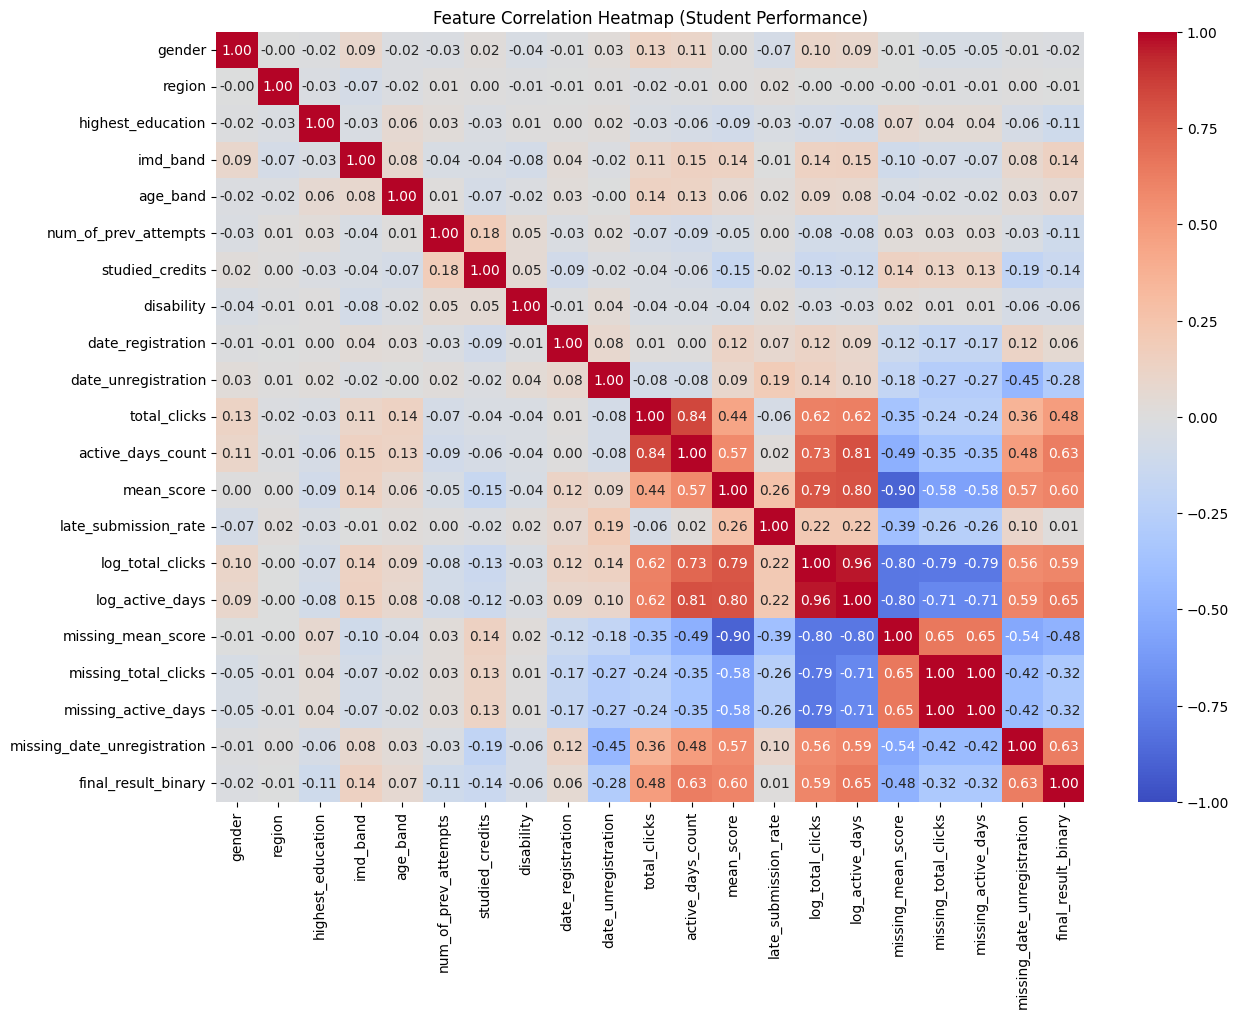


Top Correlations with Success (final_result_binary):
final_result_binary            1.00
log_active_days                0.65
missing_date_unregistration    0.63
active_days_count              0.63
mean_score                     0.60
log_total_clicks               0.59
total_clicks                   0.48
imd_band                       0.14
age_band                       0.07
date_registration              0.06
late_submission_rate           0.01
region                        -0.01
gender                        -0.02
disability                    -0.06
num_of_prev_attempts          -0.11
highest_education             -0.11
studied_credits               -0.14
date_unregistration           -0.28
missing_active_days           -0.32
missing_total_clicks          -0.32
missing_mean_score            -0.48
Name: final_result_binary, dtype: float64


In [17]:
#heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df_heatmap.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap (Student Performance)')
plt.show()

print("\nTop Correlations with Success (final_result_binary):")
print(corr_matrix['final_result_binary'].sort_values(ascending=False))

In [18]:
keep_cols =[
    'final_result',
    'log_active_days',
    'mean_score',
    'log_total_clicks',
    'studied_credits',
    'num_of_prev_attempts',
    'imd_band',
    'highest_education',
    'age_band',
    'disability'
]

df_final = merged_df[keep_cols].copy()

In [19]:
# Clean categoricals and fill blanks with 'Unknown' before encoding
categorical_cols = ['imd_band']  # Only columns in keep_cols
cat_cols = ['imd_band', 'highest_education', 'age_band']

for col in categorical_cols:
    # Normalize strings and replace common missing tokens
    df_final[col] = df_final[col].astype(str).str.strip()
    df_final[col] = df_final[col].replace(['', 'NaN', 'nan', 'None', 'null'], 'Unknown')
    df_final[col] = df_final[col].fillna('Unknown')

print("Categorical columns filled/normalized with 'Unknown':")
for col in categorical_cols:
    print(f"{col}: {df_final[col].unique()[:5]}...")

Categorical columns filled/normalized with 'Unknown':
imd_band: ['90-100%' '20-30%' '30-40%' '50-60%' '80-90%']...


In [20]:
# DEBUG: Check categorical values before encoding to catch unmapped categories
print("=== Debug: Values BEFORE encoding ===")
for col in ['imd_band', 'highest_education', 'age_band']:
    if col in df_final.columns:
        print(f"\n{col}:")
        print(f"  Unique: {df_final[col].unique()}")
        print(f"  NaN count: {df_final[col].isna().sum()}")
        print(f"  Value counts:\n{df_final[col].value_counts(dropna=False)}")

=== Debug: Values BEFORE encoding ===

imd_band:
  Unique: ['90-100%' '20-30%' '30-40%' '50-60%' '80-90%' '70-80%' 'Unknown' '60-70%'
 '40-50%' '10-20' '0-10%']
  NaN count: 0
  Value counts:
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Unknown    1111
Name: count, dtype: int64

highest_education:
  Unique: ['HE Qualification' 'A Level or Equivalent' 'Lower Than A Level'
 'Post Graduate Qualification' 'No Formal quals']
  NaN count: 0
  Value counts:
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

age_band:
  Unique: ['55<=' '35-55' '0-35']
  NaN count: 0
  Value counts:
age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64


In [21]:
#encode
education_map = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4,
}

In [22]:
age_map = {
    '0-35': 0,
    '35-55': 1,
    '55<=': 2,
}

In [23]:
imd_map = {
    '0-10%': 0, '10-20': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9,
    'Unknown': 10
}

In [24]:
map={
    'highest_education': education_map,
    'age_band': age_map,
    'imd_band': imd_map
}

for col, mapping in map.items():
    df_final[col] = df_final[col].map(mapping)

In [25]:
df_final['final_result_binary'] = df_final['final_result'].map({
    'Pass': 1, 'Distinction': 1, 'Fail': 0, 'Withdrawn': 0
})

df_final['disability'] = df_final['disability'].map({'N': 0, 'Y': 1})

In [26]:
df_final = df_final.drop(columns=['final_result'])
X = df_final.drop(columns=['final_result_binary'])
y = df_final['final_result_binary']


In [27]:
print(f"Features Selected ({len(X.columns)}): {list(X.columns)}")
display(X.head(20))


Features Selected (9): ['log_active_days', 'mean_score', 'log_total_clicks', 'studied_credits', 'num_of_prev_attempts', 'imd_band', 'highest_education', 'age_band', 'disability']


,log_active_days,mean_score,log_total_clicks,studied_credits,num_of_prev_attempts,imd_band,highest_education,age_band,disability
0,3.71,82.00,6.84,240,0,9,3,2,0
1,4.39,66.40,7.27,60,0,2,3,1,0
2,2.56,0.00,5.64,60,0,3,2,1,1
3,4.82,76.00,7.68,60,0,5,2,1,0
4,4.26,54.40,6.94,60,0,5,1,0,0
5,4.97,68.00,7.80,60,0,8,2,1,0
6,4.51,68.00,7.31,60,0,3,3,0,0
7,4.66,72.40,7.26,120,0,9,2,0,0
8,4.81,71.40,7.55,90,0,7,2,0,0
9,4.96,78.00,8.06,60,0,10,4,2,0


In [28]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   log_active_days       32593 non-null  float64
 1   mean_score            32593 non-null  float64
 2   log_total_clicks      32593 non-null  float64
 3   studied_credits       32593 non-null  int64  
 4   num_of_prev_attempts  32593 non-null  int64  
 5   imd_band              32593 non-null  int64  
 6   highest_education     32593 non-null  int64  
 7   age_band              32593 non-null  int64  
 8   disability            32593 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 2.2 MB


# **Model Building & Evaluation**

Now that preprocessing is complete, we'll:
1. Split data into train/validation/test sets (70/15/15)
2. Train multiple models (Decision Tree, Random Forest, Logistic Regression)
3. Evaluate and compare performance
4. Select best model and test on hold-out set

In [29]:
# Stratified train/validation/test split (70/15/15)
from sklearn.model_selection import train_test_split

print(f"Target distribution:\n{y.value_counts()}")
print(f"Target balance: {y.mean():.2%} pass rate\n")

# First split: 70% train, 30% temp (which becomes 15% val + 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: split temp into 50/50 (15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set: {len(X_train)} samples ({y_train.mean():.2%} pass)")
print(f"Val set:   {len(X_val)} samples ({y_val.mean():.2%} pass)")
print(f"Test set:  {len(X_test)} samples ({y_test.mean():.2%} pass)")

print(f"\nFeature count: {len(X.columns)}")
print(f"Features: {list(X.columns)}")

Target distribution:
final_result_binary
0    17208
1    15385
Name: count, dtype: int64
Target balance: 47.20% pass rate

Train set: 22815 samples (47.20% pass)
Val set:   4889 samples (47.21% pass)
Test set:  4889 samples (47.21% pass)

Feature count: 9
Features: ['log_active_days', 'mean_score', 'log_total_clicks', 'studied_credits', 'num_of_prev_attempts', 'imd_band', 'highest_education', 'age_band', 'disability']


=== Decision Tree Performance (Validation Set) ===

Accuracy:  0.8308
Precision: 0.8049
Recall:    0.8471
F1 Score:  0.8254
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.86      0.82      0.84      2581
Pass/Distinction       0.80      0.85      0.83      2308

        accuracy                           0.83      4889
       macro avg       0.83      0.83      0.83      4889
    weighted avg       0.83      0.83      0.83      4889


Classification Report:


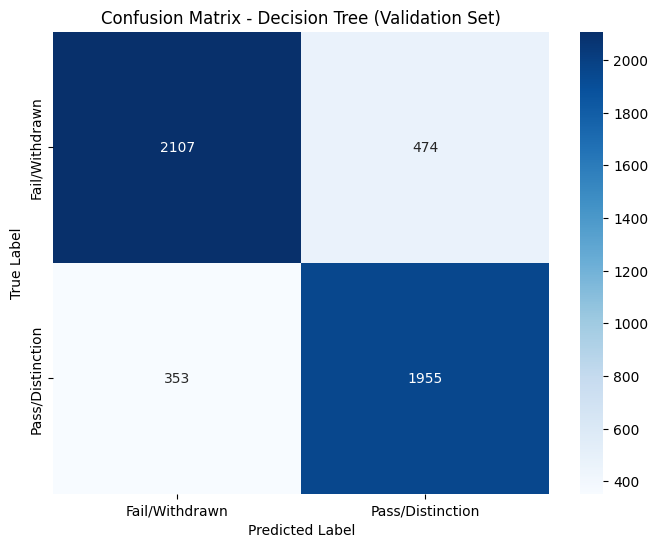

<Figure size 640x480 with 0 Axes>

In [30]:
# Train Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=100)
dt_model.fit(X_train, y_train)

# Predictions on validation set
y_val_pred_dt = dt_model.predict(X_val)

# Evaluation metrics
print("=== Decision Tree Performance (Validation Set) ===\n")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_dt):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_dt):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred_dt):.4f}")

# Confusion Matrix Heatmap
cm_dt = confusion_matrix(y_val, y_val_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail/Withdrawn', 'Pass/Distinction'],

            yticklabels=['Fail/Withdrawn', 'Pass/Distinction'])
print(classification_report(y_val, y_val_pred_dt, target_names=['Fail/Withdrawn', 'Pass/Distinction']))

plt.title('Confusion Matrix - Decision Tree (Validation Set)')
print("\nClassification Report:")

plt.ylabel('True Label')

plt.xlabel('Predicted Label')
plt.show()
plt.tight_layout()

=== Random Forest Performance (Validation Set) ===

Accuracy:  0.8478
Precision: 0.8258
Recall:    0.8588
F1 Score:  0.8420
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.87      0.84      0.85      2581
Pass/Distinction       0.83      0.86      0.84      2308

        accuracy                           0.85      4889
       macro avg       0.85      0.85      0.85      4889
    weighted avg       0.85      0.85      0.85      4889


Classification Report:


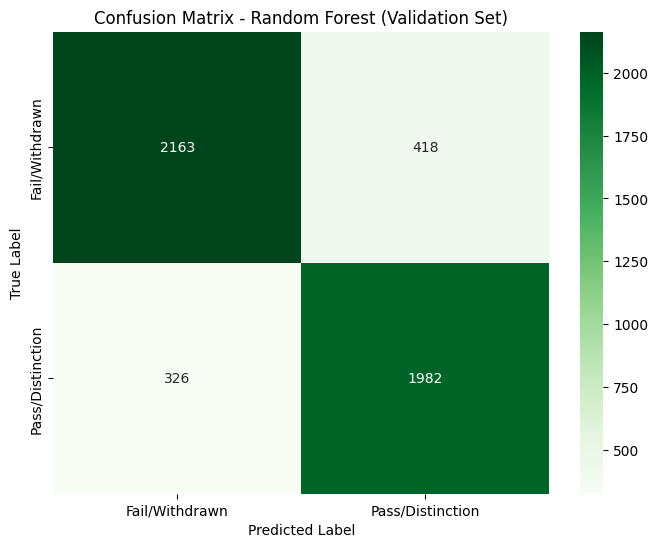

<Figure size 640x480 with 0 Axes>

In [31]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, min_samples_split=100)
rf_model.fit(X_train, y_train)

# Predictions on validation set
y_val_pred_rf = rf_model.predict(X_val)

# Evaluation metrics
print("=== Random Forest Performance (Validation Set) ===\n")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred_rf):.4f}")

# Confusion Matrix Heatmap
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Fail/Withdrawn', 'Pass/Distinction'],

            yticklabels=['Fail/Withdrawn', 'Pass/Distinction'])
print(classification_report(y_val, y_val_pred_rf, target_names=['Fail/Withdrawn', 'Pass/Distinction']))

plt.title('Confusion Matrix - Random Forest (Validation Set)')
print("\nClassification Report:")

plt.ylabel('True Label')

plt.xlabel('Predicted Label')    
plt.show()
plt.tight_layout()

=== Logistic Regression Performance (Validation Set) ===

Accuracy:  0.8335
Precision: 0.7953
Recall:    0.8718
F1 Score:  0.8317
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.87      0.80      0.84      2581
Pass/Distinction       0.80      0.87      0.83      2308

        accuracy                           0.83      4889
       macro avg       0.83      0.84      0.83      4889
    weighted avg       0.84      0.83      0.83      4889


Classification Report:


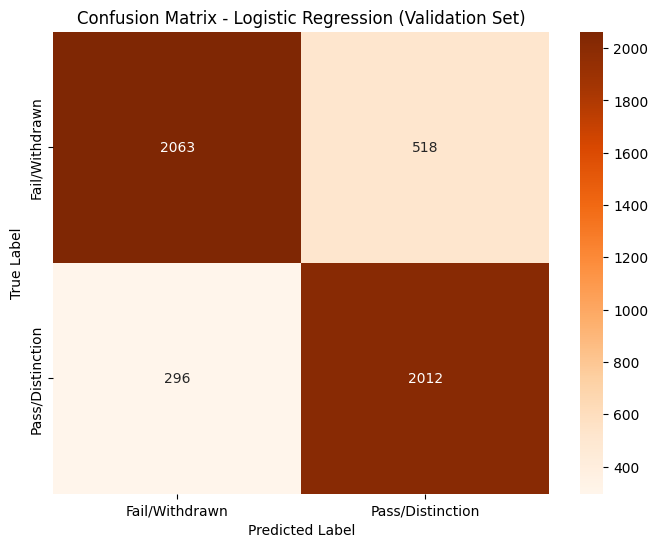

<Figure size 640x480 with 0 Axes>

In [32]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

# Predictions on validation set
y_val_pred_lr = lr_model.predict(X_val)

# Evaluation metrics
print("=== Logistic Regression Performance (Validation Set) ===\n")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred_lr):.4f}")

# Confusion Matrix Heatmap
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Fail/Withdrawn', 'Pass/Distinction'],

            yticklabels=['Fail/Withdrawn', 'Pass/Distinction'])
print(classification_report(y_val, y_val_pred_lr, target_names=['Fail/Withdrawn', 'Pass/Distinction']))

plt.title('Confusion Matrix - Logistic Regression (Validation Set)')
print("\nClassification Report:")

plt.ylabel('True Label')

plt.xlabel('Predicted Label')    
plt.show()
plt.tight_layout()

In [33]:
# Compare all models
import pandas as pd

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_val, y_val_pred_dt),
        accuracy_score(y_val, y_val_pred_rf),
        accuracy_score(y_val, y_val_pred_lr)
    ],
    'Precision': [
        precision_score(y_val, y_val_pred_dt),
        precision_score(y_val, y_val_pred_rf),
        precision_score(y_val, y_val_pred_lr)
    ],
    'Recall': [
        recall_score(y_val, y_val_pred_dt),
        recall_score(y_val, y_val_pred_rf),
        recall_score(y_val, y_val_pred_lr)
    ],
    'F1 Score': [
        f1_score(y_val, y_val_pred_dt),
        f1_score(y_val, y_val_pred_rf),
        f1_score(y_val, y_val_pred_lr)
    ]
})

print("=== Model Comparison (Validation Set) ===\n")
display(results.style.highlight_max(axis=0, subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'], color='red'))

# Identify best model
best_model_idx = results['F1 Score'].idxmax()
best_model_name = results.loc[best_model_idx, 'Model']
print(f"\nBest model based on F1 Score: {best_model_name}")

=== Model Comparison (Validation Set) ===



,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.830845,0.804858,0.847054,0.825417
1,Random Forest,0.847822,0.825833,0.858752,0.841971
2,Logistic Regression,0.833504,0.795257,0.871750,0.831749



Best model based on F1 Score: Random Forest


=== Final Test Set Performance (Best Model) ===

Model: Random Forest
Accuracy:  0.8464
Precision: 0.8216
Recall:    0.8618
F1 Score:  0.8412
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.87      0.83      0.85      2581
Pass/Distinction       0.82      0.86      0.84      2308

        accuracy                           0.85      4889
       macro avg       0.85      0.85      0.85      4889
    weighted avg       0.85      0.85      0.85      4889


Classification Report:


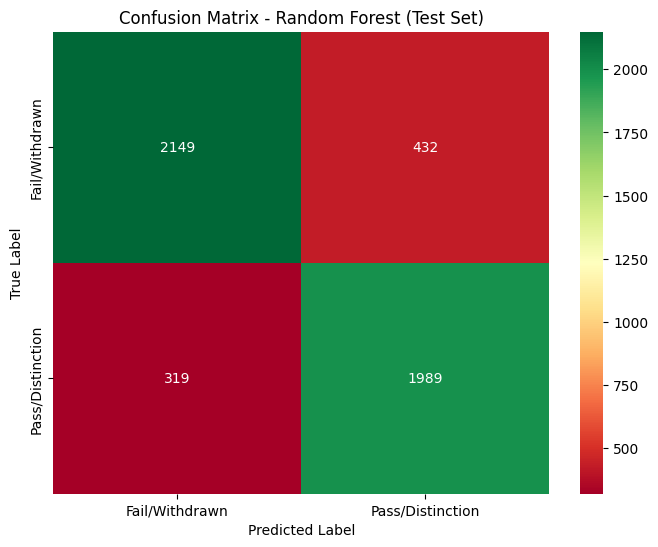

<Figure size 640x480 with 0 Axes>

In [34]:
# Evaluate best model on the held-out test set
model_map = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Logistic Regression': lr_model
}

best_model = model_map.get(best_model_name)
if best_model is None:
    print("Best model name not recognized. Available:", list(model_map.keys()))
else:
    y_test_pred = best_model.predict(X_test)
    print("=== Final Test Set Performance (Best Model) ===\n")
    print(f"Model: {best_model_name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_test_pred):.4f}")

    # Confusion Matrix Heatmap
    cm_test = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='RdYlGn', 
                xticklabels=['Fail/Withdrawn', 'Pass/Distinction'],

                yticklabels=['Fail/Withdrawn', 'Pass/Distinction'])    
    print(classification_report(y_test, y_test_pred, target_names=['Fail/Withdrawn', 'Pass/Distinction']))

    plt.title(f'Confusion Matrix - {best_model_name} (Test Set)')    
    print("\nClassification Report:")

    plt.ylabel('True Label')

    plt.xlabel('Predicted Label')    
    plt.show()
    plt.tight_layout()

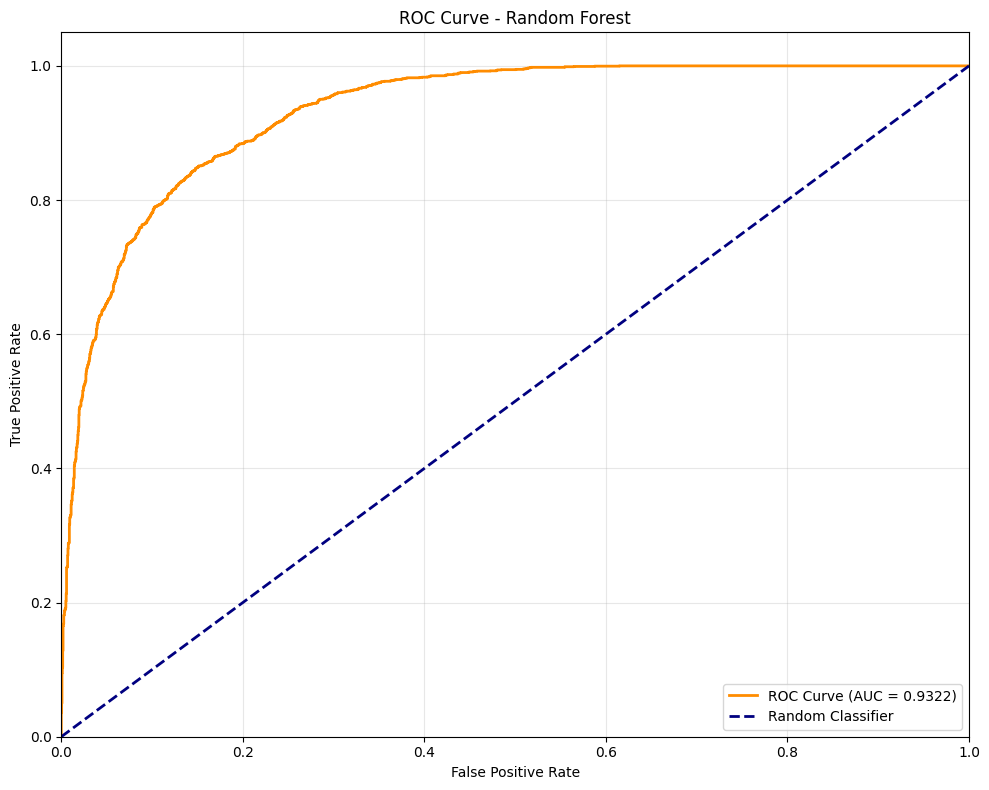


=== ROC Curve Analysis (Random Forest) ===
AUC Score: 0.9322

Interpretation:
  AUC = 1.0: Perfect classifier
  AUC = 0.5: Random classifier
  AUC = 0.9322: Model performance


In [35]:

# ROC Curve for Best Model (Random Forest)
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n=== ROC Curve Analysis ({best_model_name}) ===")
print(f"AUC Score: {roc_auc:.4f}")
print(f"\nInterpretation:")
print(f"  AUC = 1.0: Perfect classifier")
print(f"  AUC = 0.5: Random classifier")
print(f"  AUC = {roc_auc:.4f}: Model performance")


# **Feature Importance & Visualization**
Best model is Random Forest, so use Random Forest feature importance and correlation analysis to highlight predictors (attendance, prior attempts, demographics).

In [36]:
# Feature importance
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

display(feature_importance_df)

,Feature,Importance
0,log_active_days,0.41
1,mean_score,0.27
2,log_total_clicks,0.27
3,studied_credits,0.03
6,highest_education,0.01
5,imd_band,0.01
4,num_of_prev_attempts,0.00
7,age_band,0.00
8,disability,0.00


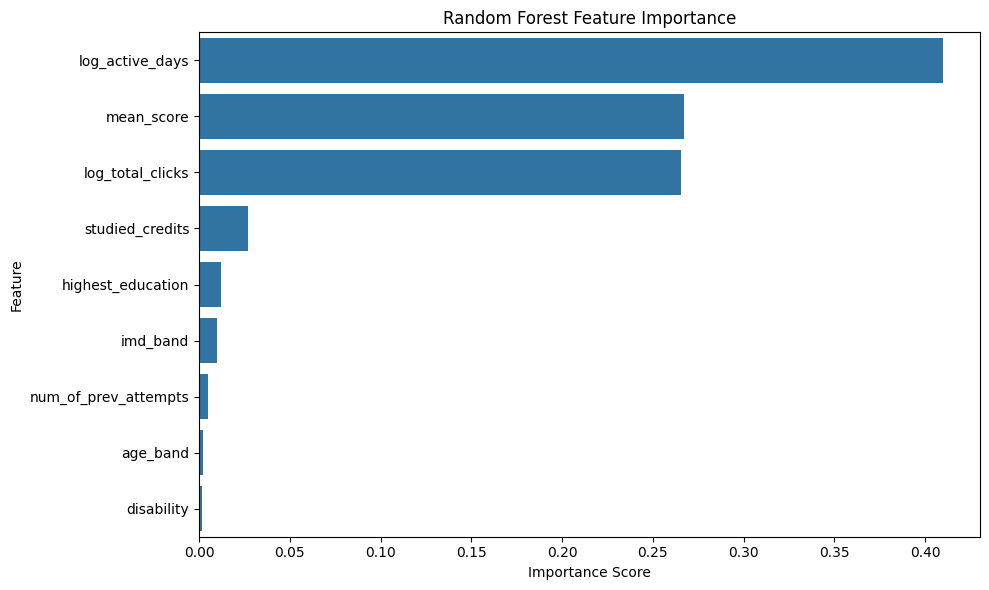

In [37]:
# Bar Plot for Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature',
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

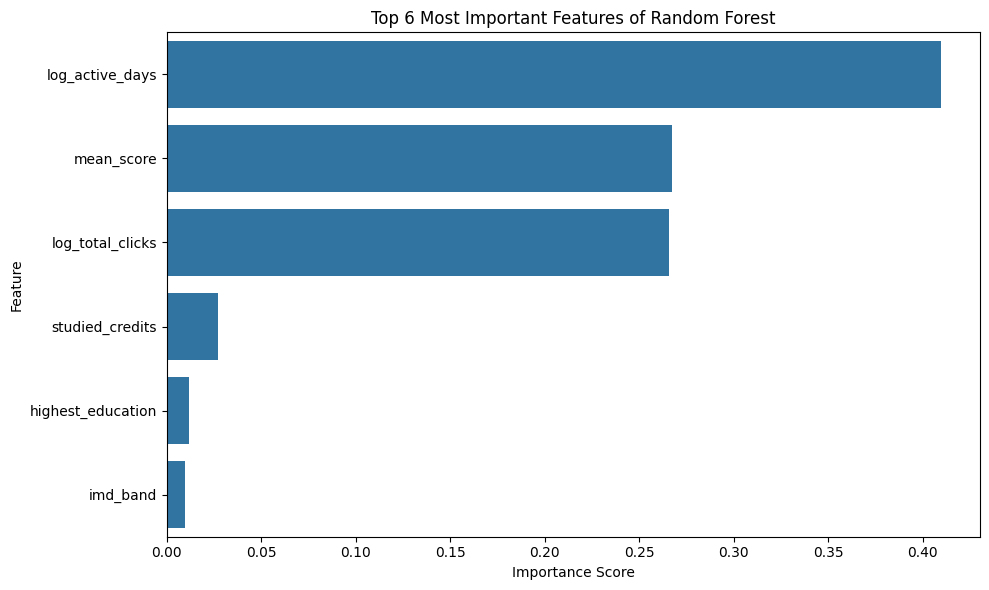

In [38]:
# Barplot for Feature Importance (Focused on Top 6)
top_n = feature_importance_df.head(6)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_n, x='Importance', y='Feature',)

plt.title('Top 6 Most Important Features of Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

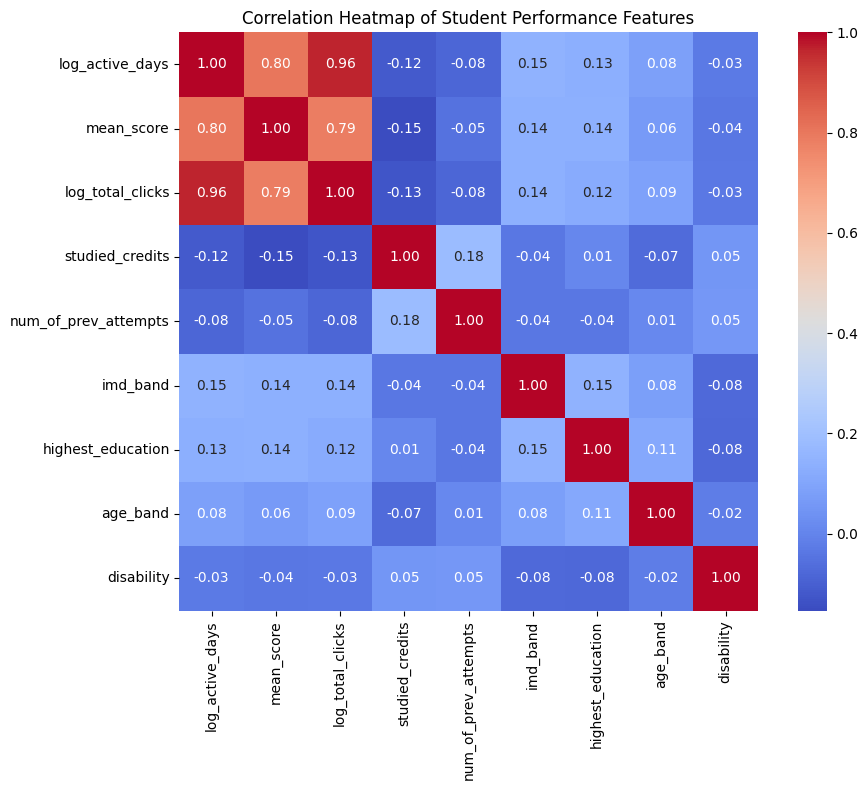

In [39]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_final.drop(columns=['final_result_binary']).corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)

plt.title('Correlation Heatmap of Student Performance Features')
plt.tight_layout()
plt.show()

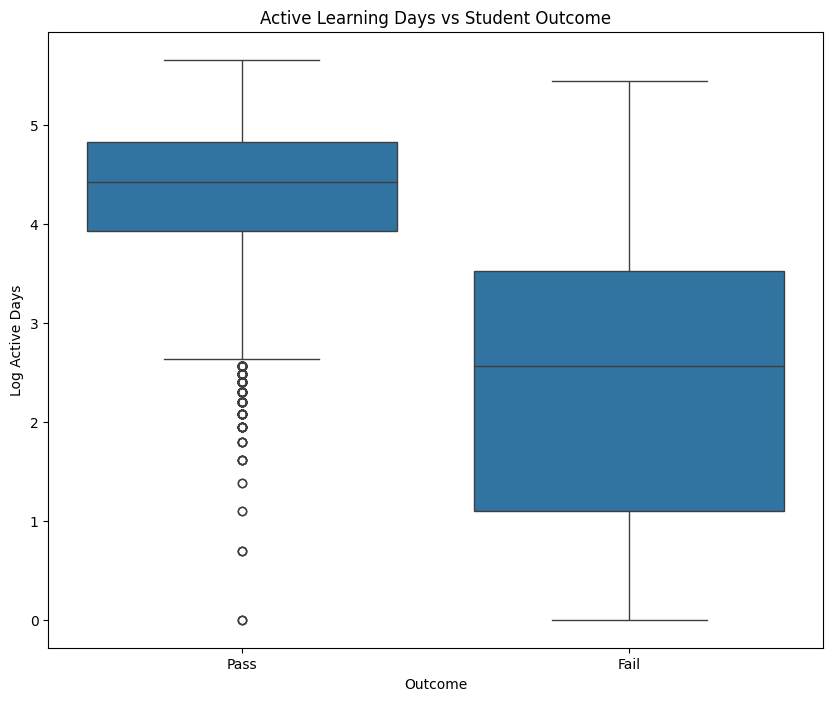

In [40]:
# Boxplots of Outcome vs Engagement
df_viz = df_final.copy()
df_viz['Outcome'] = df_viz['final_result_binary'].map({1: 'Pass', 0: 'Fail'})

plt.figure(figsize=(10,8))
sns.boxplot(data=df_viz, x='Outcome', y='log_active_days')

plt.title('Active Learning Days vs Student Outcome')
plt.ylabel('Log Active Days')
plt.show()

In [41]:
import joblib

# Save the best model (determined by F1 score comparison)
joblib.dump(best_model, "best_model.joblib")
joblib.dump(best_model_name, "best_model_name.txt")
joblib.dump(list(X_train.columns), "feature_cols.joblib")

print(f"Saved best model: {best_model_name}")
print("Files: best_model.joblib, best_model_name.txt, feature_cols.joblib")

Saved best model: Random Forest
Files: best_model.joblib, best_model_name.txt, feature_cols.joblib
